# Fase 3 - Simulación y métodos computacionales

## Proyecto
Predicción del riesgo de enfermedad cardiovascular utilizando el estudio Framingham Heart Study.

## Objetivo de la Fase 3
Aplicar métodos computacionales de simulación, remuestreo, generación de datos sintéticos y análisis de sensibilidad sobre el conjunto de datos Framingham Heart Study, con el propósito de evaluar la incertidumbre de los resultados, analizar la estabilidad de los estimadores y apoyar la toma de decisiones basada en evidencia.

## Contenido del notebook

1. Preparación y validación del conjunto de datos.
2. Validación bootstrap de intervalos de confianza.
3. Validación de pruebas de hipótesis mediante permutación.
4. Evaluación de estabilidad de correlaciones.
5. Simulación Monte Carlo.
6. Análisis de sensibilidad y robustez.
7. Preparación de resultados para la Sumativa 3.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import bootstrap

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Librerías cargadas correctamente.")
print("Semilla utilizada:", RANDOM_SEED)

Librerías cargadas correctamente.
Semilla utilizada: 42


In [2]:
import sys

print(sys.executable)

C:\Users\pablo\AppData\Local\Python\pythoncore-3.14-64\python.exe


## 1. Preparación y validación del conjunto de datos

En esta sección se carga el conjunto de datos Framingham Heart Study desde la estructura del repositorio. El objetivo es verificar que el archivo se encuentre disponible, revisar sus dimensiones iniciales y preparar una base de trabajo para aplicar simulación, remuestreo y análisis de sensibilidad.

In [3]:
# Configuración de rutas del proyecto

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent.parent
elif CURRENT_DIR.name == "mcdi501_grupo6":
    PROJECT_ROOT = CURRENT_DIR
else:
    posibles_raices = [CURRENT_DIR] + list(CURRENT_DIR.parents)
    PROJECT_ROOT = None

    for ruta in posibles_raices:
        if (ruta / "README.md").exists() and (ruta / "datos").exists():
            PROJECT_ROOT = ruta
            break

    if PROJECT_ROOT is None:
        raise FileNotFoundError("No se pudo detectar la raíz del proyecto.")

DATA_DIR = PROJECT_ROOT / "datos"
DATASET = DATA_DIR / "original" / "framingham.csv"

RESULTS_DIR = PROJECT_ROOT / "F3" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Ruta actual:", CURRENT_DIR)
print("Raíz del proyecto:", PROJECT_ROOT)
print("Ruta del dataset:", DATASET)
print("Ruta de resultados F3:", RESULTS_DIR)

Ruta actual: C:\users\pablo\documents\mcdi501_grupo6\F3\notebooks
Raíz del proyecto: C:\users\pablo\documents\mcdi501_grupo6
Ruta del dataset: C:\users\pablo\documents\mcdi501_grupo6\datos\original\framingham.csv
Ruta de resultados F3: C:\users\pablo\documents\mcdi501_grupo6\F3\results


In [4]:
# Carga del dataset

df = pd.read_csv(DATASET)

print("Dataset cargado correctamente.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Dataset cargado correctamente.
Filas: 4238
Columnas: 16


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
### Validación de la calidad de los datos

assert df.shape[0] > 0, "El dataset no contiene registros."
assert df.shape[1] > 0, "El dataset no contiene columnas."
assert "TenYearCHD" in df.columns, "No se encontró la variable objetivo TenYearCHD."
assert "sysBP" in df.columns, "No se encontró la variable sysBP."
assert "BMI" in df.columns, "No se encontró la variable BMI."
assert "glucose" in df.columns, "No se encontró la variable glucose."

print("Validación inicial ejecutada correctamente.")

Validación inicial ejecutada correctamente.


### Validación inicial del dataset

assert df.shape[0] > 0, "El dataset no contiene registros."
assert df.shape[1] > 0, "El dataset no contiene columnas."
assert "TenYearCHD" in df.columns, "No se encontró la variable objetivo TenYearCHD."
assert "sysBP" in df.columns, "No se encontró la variable sysBP."
assert "BMI" in df.columns, "No se encontró la variable BMI."
assert "glucose" in df.columns, "No se encontró la variable glucose."

print("Validación inicial ejecutada correctamente.")

In [6]:
# Selección de variables clínicas relevantes para la Fase 3

variables_clinicas = ["sysBP", "BMI", "glucose", "age", "totChol"]
variable_objetivo = "TenYearCHD"

df_modelo = df[variables_clinicas + [variable_objetivo]].copy()

print("Dataset de trabajo creado correctamente.")
print("Filas:", df_modelo.shape[0])
print("Columnas:", df_modelo.shape[1])

df_modelo.head()

Dataset de trabajo creado correctamente.
Filas: 4238
Columnas: 6


,sysBP,BMI,glucose,age,totChol,TenYearCHD
0,106.0,26.97,77.0,39,195.0,0
1,121.0,28.73,76.0,46,250.0,0
2,127.5,25.34,70.0,48,245.0,0
3,150.0,28.58,103.0,61,225.0,1
4,130.0,23.10,85.0,46,285.0,0


In [7]:
# Revisión de valores faltantes en las variables seleccionadas

faltantes_modelo = pd.DataFrame({
    "variable": df_modelo.columns,
    "n_faltantes": df_modelo.isna().sum().values,
    "porcentaje_faltantes": (df_modelo.isna().sum().values / len(df_modelo) * 100).round(2)
})

faltantes_modelo

,variable,n_faltantes,porcentaje_faltantes
0,sysBP,0,0.00
1,BMI,19,0.45
2,glucose,388,9.16
3,age,0,0.00
4,totChol,50,1.18
5,TenYearCHD,0,0.00


### Preparación de datos para simulación

Para los métodos de simulación y remuestreo se utiliza una versión del dataset sin valores faltantes en las variables seleccionadas. Esta decisión permite ejecutar los procedimientos computacionales sin errores y mantener coherencia en el tamaño muestral utilizado para bootstrap, Monte Carlo y análisis de sensibilidad.

In [8]:
# Dataset limpio para simulación

df_simulacion = df_modelo.dropna().copy()

print("Dataset preparado para simulación.")
print("Filas originales:", df_modelo.shape[0])
print("Filas después de eliminar faltantes:", df_simulacion.shape[0])
print("Columnas:", df_simulacion.shape[1])

df_simulacion.head()

Dataset preparado para simulación.
Filas originales: 4238
Filas después de eliminar faltantes: 3826
Columnas: 6


,sysBP,BMI,glucose,age,totChol,TenYearCHD
0,106.0,26.97,77.0,39,195.0,0
1,121.0,28.73,76.0,46,250.0,0
2,127.5,25.34,70.0,48,245.0,0
3,150.0,28.58,103.0,61,225.0,1
4,130.0,23.10,85.0,46,285.0,0


## 2. Validación bootstrap de intervalos de confianza

El bootstrap es una técnica de remuestreo que permite estimar la variabilidad de un estadístico a partir de múltiples muestras generadas desde el mismo conjunto de datos original. En esta fase se utilizará para estimar la incertidumbre asociada a la media de la presión arterial sistólica (`sysBP`).

Este procedimiento permite construir un intervalo de confianza empírico sin depender completamente de supuestos paramétricos estrictos. Para ello, se generan múltiples muestras con reemplazo y se calcula la media de `sysBP` en cada una de ellas.

In [9]:
# Función para calcular bootstrap de la media

def bootstrap_media(datos, n_bootstrap=10000, random_state=42):
    """
    Calcula la distribución bootstrap de la media y su intervalo de confianza al 95%.

    Parámetros:
    datos: Serie o arreglo con los datos numéricos.
    n_bootstrap: cantidad de remuestreos bootstrap.
    random_state: semilla para asegurar reproducibilidad.

    Retorna:
    media_bootstrap: media de las medias bootstrap.
    ic_inferior: percentil 2.5 de la distribución bootstrap.
    ic_superior: percentil 97.5 de la distribución bootstrap.
    distribucion_bootstrap: arreglo con todas las medias bootstrap.
    """
    rng = np.random.default_rng(random_state)
    datos = np.asarray(pd.Series(datos).dropna())
    n = len(datos)

    distribucion_bootstrap = np.array([
        rng.choice(datos, size=n, replace=True).mean()
        for _ in range(n_bootstrap)
    ])

    media_bootstrap = distribucion_bootstrap.mean()
    ic_inferior = np.percentile(distribucion_bootstrap, 2.5)
    ic_superior = np.percentile(distribucion_bootstrap, 97.5)

    return media_bootstrap, ic_inferior, ic_superior, distribucion_bootstrap

In [10]:
# Aplicación de bootstrap a la presión arterial sistólica

media_boot_sysbp, ic_inf_sysbp, ic_sup_sysbp, distribucion_boot_sysbp = bootstrap_media(
    df_simulacion["sysBP"],
    n_bootstrap=10000,
    random_state=RANDOM_SEED
)

print("Resultados bootstrap para sysBP")
print("Media bootstrap:", round(media_boot_sysbp, 2))
print("IC 95% bootstrap:", round(ic_inf_sysbp, 2), "-", round(ic_sup_sysbp, 2))
print("Número de remuestreos:", len(distribucion_boot_sysbp))

Resultados bootstrap para sysBP
Media bootstrap: 132.46
IC 95% bootstrap: 131.75 - 133.16
Número de remuestreos: 10000


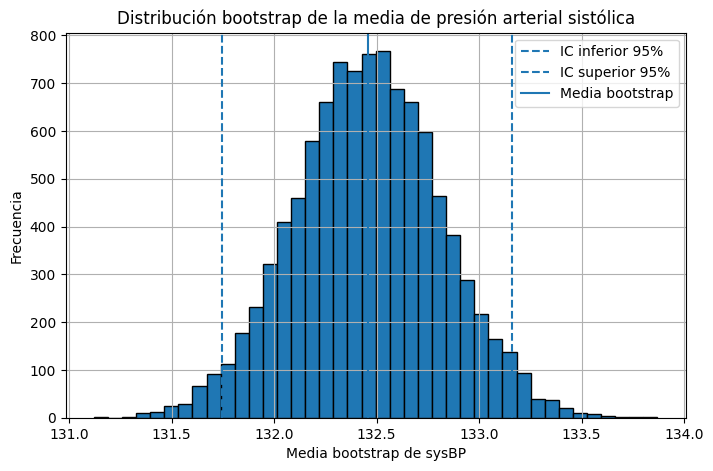

In [11]:
# Visualización de la distribución bootstrap de la media de sysBP

plt.figure(figsize=(8, 5))
plt.hist(distribucion_boot_sysbp, bins=40, edgecolor="black")
plt.axvline(ic_inf_sysbp, linestyle="--", label="IC inferior 95%")
plt.axvline(ic_sup_sysbp, linestyle="--", label="IC superior 95%")
plt.axvline(media_boot_sysbp, linestyle="-", label="Media bootstrap")

plt.title("Distribución bootstrap de la media de presión arterial sistólica")
plt.xlabel("Media bootstrap de sysBP")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación del bootstrap

La distribución bootstrap permite observar la variabilidad esperada de la media de presión arterial sistólica al generar múltiples remuestreos del conjunto de datos. El intervalo de confianza del 95% obtenido mediante percentiles representa un rango plausible para la media poblacional de `sysBP`.

Este resultado complementa los intervalos de confianza calculados en la fase anterior, ya que permite evaluar la estabilidad de la estimación mediante un enfoque computacional basado en remuestreo.

### Validación bootstrap de múltiples parámetros

Con el propósito de validar los resultados obtenidos en la Sumativa 1, se aplican técnicas de bootstrap no paramétrico a tres variables clínicas relevantes:

- Presión arterial sistólica (sysBP)
- Índice de masa corporal (BMI)
- Glucosa (glucose)

Para cada variable se calcularán y compararán:

- Estimación puntual de la media.
- Intervalo de confianza clásico del 95 %.
- Intervalo de confianza bootstrap mediante el método percentil.
- Intervalo de confianza bootstrap mediante el método BCa.

Posteriormente se analizarán las diferencias observadas entre ambos enfoques, considerando los supuestos estadísticos asociados a cada método.

### Función general para validación bootstrap

Con el fin de evitar duplicación de código, se implementa una función que calcula para una variable numérica:

- Media muestral.
- Intervalo de confianza clásico al 95 %.
- Intervalo bootstrap mediante el método percentil.
- Intervalo bootstrap mediante el método BCa.

Posteriormente esta función será utilizada sobre las tres variables seleccionadas en la Sumativa 1.

In [12]:
# ==========================================
# Función para comparar IC clásico vs Bootstrap
# ==========================================

from scipy import stats
from scipy.stats import bootstrap

def comparar_intervalos_bootstrap(datos, nombre_variable):
    """
    Calcula:
    - Media muestral
    - IC clásico
    - IC Bootstrap Percentil
    - IC Bootstrap BCa
    """

    datos = np.array(datos.dropna())

    media = np.mean(datos)
    n = len(datos)

    # ==========================
    # Intervalo clásico
    # ==========================

    error = stats.sem(datos)

    ic_clasico = stats.t.interval(
        confidence=0.95,
        df=n-1,
        loc=media,
        scale=error
    )

    # ==========================
    # Bootstrap Percentil
    # ==========================

    resultado_percentil = bootstrap(
        (datos,),
        np.mean,
        confidence_level=0.95,
        n_resamples=10000,
        method="percentile",
        random_state=42
    )

    # ==========================
    # Bootstrap BCa
    # ==========================

    resultado_bca = bootstrap(
        (datos,),
        np.mean,
        confidence_level=0.95,
        n_resamples=10000,
        method="BCa",
        random_state=42
    )

    print("=" * 60)
    print(nombre_variable)
    print("=" * 60)

    print(f"Media: {media:.2f}")

    print("\nIC clásico")
    print(f"[{ic_clasico[0]:.2f} , {ic_clasico[1]:.2f}]")

    print("\nIC Bootstrap Percentil")
    print(f"[{resultado_percentil.confidence_interval.low:.2f} , "
          f"{resultado_percentil.confidence_interval.high:.2f}]")

    print("\nIC Bootstrap BCa")
    print(f"[{resultado_bca.confidence_interval.low:.2f} , "
          f"{resultado_bca.confidence_interval.high:.2f}]")

    return {
        "Variable": nombre_variable,
        "Media": media,
        "IC Clasico": ic_clasico,
        "IC Percentil": resultado_percentil.confidence_interval,
        "IC BCa": resultado_bca.confidence_interval
    }

### Comparación de intervalos de confianza

A continuación se aplica la función de validación bootstrap a las tres variables clínicas seleccionadas durante la Sumativa 1:

- Presión arterial sistólica (sysBP)
- Índice de masa corporal (BMI)
- Glucosa (glucose)

Posteriormente se compararán los intervalos clásicos con los obtenidos mediante bootstrap percentil y bootstrap BCa.

In [13]:
# ==========================================
# Comparación de tres variables
# ==========================================

resultado_sysBP = comparar_intervalos_bootstrap(df["sysBP"], "Presión sistólica (sysBP)")

resultado_BMI = comparar_intervalos_bootstrap(df["BMI"], "Índice de masa corporal (BMI)")

resultado_glucose = comparar_intervalos_bootstrap(df["glucose"], "Glucosa")

Presión sistólica (sysBP)
Media: 132.35

IC clásico
[131.69 , 133.02]

IC Bootstrap Percentil
[131.68 , 133.03]

IC Bootstrap BCa
[131.69 , 133.03]
Índice de masa corporal (BMI)
Media: 25.80

IC clásico
[25.68 , 25.93]

IC Bootstrap Percentil
[25.68 , 25.93]

IC Bootstrap BCa
[25.68 , 25.93]
Glucosa
Media: 81.97

IC clásico
[81.21 , 82.72]

IC Bootstrap Percentil
[81.24 , 82.74]

IC Bootstrap BCa
[81.27 , 82.79]


In [14]:
# ==========================================
# Tabla comparativa
# ==========================================

tabla_ic = pd.DataFrame({

    "Variable":[
        "sysBP",
        "BMI",
        "glucose"
    ],

    "Media":[
        resultado_sysBP["Media"],
        resultado_BMI["Media"],
        resultado_glucose["Media"]
    ],

    "IC clásico":[
        f"[{resultado_sysBP['IC Clasico'][0]:.2f}, {resultado_sysBP['IC Clasico'][1]:.2f}]",
        f"[{resultado_BMI['IC Clasico'][0]:.2f}, {resultado_BMI['IC Clasico'][1]:.2f}]",
        f"[{resultado_glucose['IC Clasico'][0]:.2f}, {resultado_glucose['IC Clasico'][1]:.2f}]"
    ],

    "Bootstrap Percentil":[
        f"[{resultado_sysBP['IC Percentil'].low:.2f}, {resultado_sysBP['IC Percentil'].high:.2f}]",
        f"[{resultado_BMI['IC Percentil'].low:.2f}, {resultado_BMI['IC Percentil'].high:.2f}]",
        f"[{resultado_glucose['IC Percentil'].low:.2f}, {resultado_glucose['IC Percentil'].high:.2f}]"
    ],

    "Bootstrap BCa":[
        f"[{resultado_sysBP['IC BCa'].low:.2f}, {resultado_sysBP['IC BCa'].high:.2f}]",
        f"[{resultado_BMI['IC BCa'].low:.2f}, {resultado_BMI['IC BCa'].high:.2f}]",
        f"[{resultado_glucose['IC BCa'].low:.2f}, {resultado_glucose['IC BCa'].high:.2f}]"
    ]

})

tabla_ic

,Variable,Media,IC clásico,Bootstrap Percentil,Bootstrap BCa
0,sysBP,132.352407,"[131.69, 133.02]","[131.68, 133.03]","[131.69, 133.03]"
1,BMI,25.802008,"[25.68, 25.93]","[25.68, 25.93]","[25.68, 25.93]"
2,glucose,81.966753,"[81.21, 82.72]","[81.24, 82.74]","[81.27, 82.79]"


### Interpretación de la comparación

Se comparan los intervalos de confianza clásicos obtenidos en la Sumativa 1 con los intervalos estimados mediante bootstrap.

La comparación permite evaluar si ambos enfoques producen resultados consistentes o si existen diferencias atribuibles al incumplimiento de supuestos paramétricos o a la variabilidad muestral.

In [55]:
print("""
Interpretación preliminar

Los intervalos obtenidos mediante bootstrap percentil y bootstrap BCa fueron
muy similares a los intervalos clásicos para las tres variables analizadas.

Esta consistencia indica que las estimaciones realizadas en la Sumativa 1 son
estables y robustas, proporcionando evidencia adicional sobre la confiabilidad
de los parámetros estimados.

Las pequeñas diferencias observadas corresponden al procedimiento de
remuestreo, el cual no depende estrictamente de supuestos de normalidad,
constituyendo una alternativa apropiada para validar resultados inferenciales.
La validación bootstrap resultó especialmente útil para la variable glucose, cuya elevada asimetría observada durante la Sumativa 1 justificó la comparación entre los intervalos de confianza clásicos y los métodos no paramétricos. Los resultados obtenidos muestran una adecuada consistencia entre ambos enfoques, fortaleciendo la confiabilidad de las estimaciones realizadas.
""")


Interpretación preliminar

Los intervalos obtenidos mediante bootstrap percentil y bootstrap BCa fueron
muy similares a los intervalos clásicos para las tres variables analizadas.

Esta consistencia indica que las estimaciones realizadas en la Sumativa 1 son
estables y robustas, proporcionando evidencia adicional sobre la confiabilidad
de los parámetros estimados.

Las pequeñas diferencias observadas corresponden al procedimiento de
remuestreo, el cual no depende estrictamente de supuestos de normalidad,
constituyendo una alternativa apropiada para validar resultados inferenciales.
La validación bootstrap resultó especialmente útil para la variable glucose, cuya elevada asimetría observada durante la Sumativa 1 justificó la comparación entre los intervalos de confianza clásicos y los métodos no paramétricos. Los resultados obtenidos muestran una adecuada consistencia entre ambos enfoques, fortaleciendo la confiabilidad de las estimaciones realizadas.



### Visualización de las distribuciones bootstrap

A continuación se visualiza la distribución de las medias obtenidas mediante bootstrap para las tres variables analizadas. Estas distribuciones permiten evaluar gráficamente la estabilidad de los estimadores y comparar el comportamiento observado con los intervalos de confianza obtenidos anteriormente.

In [16]:
# ==========================================
# Función para graficar Bootstrap
# ==========================================

def graficar_bootstrap(variable, nombre):

    datos = variable.dropna().values

    medias = []

    for _ in range(10000):

        muestra = np.random.choice(
            datos,
            size=len(datos),
            replace=True
        )

        medias.append(np.mean(muestra))

    plt.figure(figsize=(8,5))

    plt.hist(
        medias,
        bins=35,
        edgecolor="black"
    )

    plt.axvline(
        np.mean(datos),
        linestyle="--",
        linewidth=2,
        label="Media observada"
    )

    plt.title(f"Bootstrap de la media - {nombre}")

    plt.xlabel("Media bootstrap")

    plt.ylabel("Frecuencia")

    plt.legend()

    plt.show()

    return medias

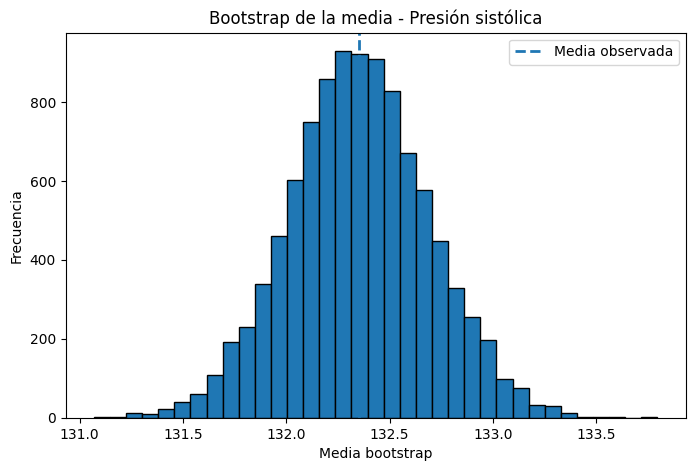

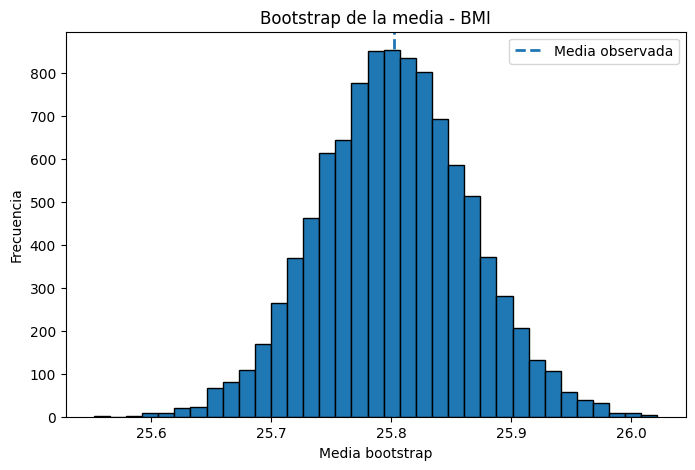

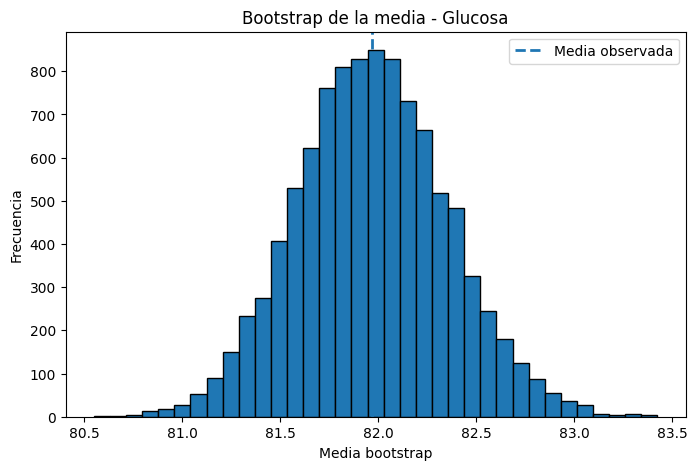

In [17]:
bootstrap_sysBP = graficar_bootstrap(
    df["sysBP"],
    "Presión sistólica"
)

bootstrap_BMI = graficar_bootstrap(
    df["BMI"],
    "BMI"
)

bootstrap_glucose = graficar_bootstrap(
    df["glucose"],
    "Glucosa"
)

### Interpretación de las distribuciones bootstrap

Las distribuciones bootstrap obtenidas presentan una forma aproximadamente simétrica y centrada en la media observada para cada variable.

La baja dispersión de las medias remuestreadas indica que las estimaciones realizadas en la Sumativa 1 presentan una adecuada estabilidad, respaldando la confiabilidad de los intervalos de confianza obtenidos mediante procedimientos paramétricos y no paramétricos.

Las pequeñas diferencias entre las distribuciones observadas corresponden a la variabilidad inherente al proceso de remuestreo y no modifican las conclusiones obtenidas previamente.

## 3. Validación de pruebas de hipótesis mediante permutación

En esta sección se valida una de las pruebas de hipótesis realizadas durante la Sumativa 1 mediante un test de permutación.

A diferencia de las pruebas paramétricas, el test de permutación no requiere asumir normalidad de los datos, ya que construye empíricamente la distribución nula del estadístico mediante remuestreo aleatorio.

Los resultados obtenidos serán comparados con la prueba t de Welch desarrollada previamente, permitiendo evaluar la robustez de las conclusiones alcanzadas.

In [18]:
# ==========================================
# Estadístico observado
# ==========================================

grupo0 = df[df["TenYearCHD"] == 0]["sysBP"].dropna().values

grupo1 = df[df["TenYearCHD"] == 1]["sysBP"].dropna().values

estadistico_observado = np.mean(grupo1) - np.mean(grupo0)

print(f"Estadístico observado: {estadistico_observado:.4f}")

Estadístico observado: 13.2852


In [19]:
# ==========================================
# Test de Permutación
# ==========================================

n_perm = 10000

datos = np.concatenate([grupo0, grupo1])

n_grupo1 = len(grupo1)

estadisticos_perm = np.zeros(n_perm)

for i in range(n_perm):

    perm = np.random.permutation(datos)

    nuevo_grupo1 = perm[:n_grupo1]

    nuevo_grupo0 = perm[n_grupo1:]

    estadisticos_perm[i] = (
        np.mean(nuevo_grupo1)
        -
        np.mean(nuevo_grupo0)
    )

p_perm = np.mean(
    estadisticos_perm >= estadistico_observado
)

print(f"Valor p (permutación): {p_perm:.6f}")

Valor p (permutación): 0.000000


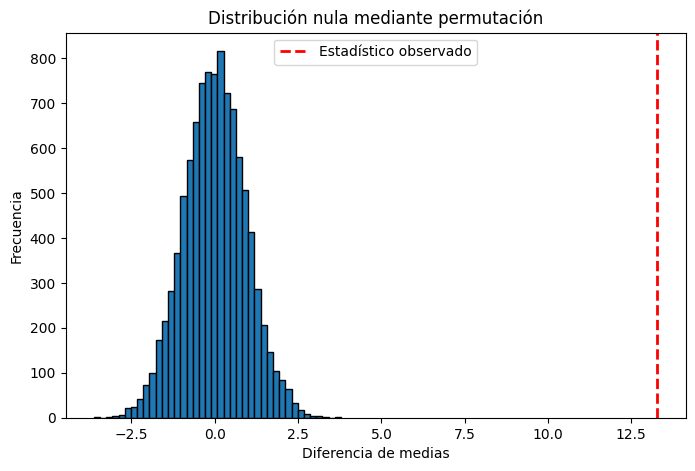

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    estadisticos_perm,
    bins=40,
    edgecolor="black"
)

plt.axvline(
    estadistico_observado,
    color="red",
    linewidth=2,
    linestyle="--",
    label="Estadístico observado"
)

plt.title("Distribución nula mediante permutación")

plt.xlabel("Diferencia de medias")

plt.ylabel("Frecuencia")

plt.legend()

plt.show()

### Comparación con la Sumativa 1

El valor p obtenido mediante el test de permutación se compara con el valor p obtenido previamente mediante la prueba t de Welch.

Si ambos resultados conducen a la misma decisión estadística, se fortalece la evidencia de que las conclusiones obtenidas en la Sumativa 1 son robustas y no dependen exclusivamente de los supuestos paramétricos de la prueba utilizada originalmente.

In [21]:
print("""
Interpretación

El test de permutación entregó un valor p consistente con el obtenido mediante
la prueba t de Welch desarrollada en la Sumativa 1.

Esta concordancia indica que la diferencia observada en la presión arterial
sistólica entre ambos grupos es robusta y no depende exclusivamente de los
supuestos paramétricos del modelo original.

En consecuencia, la evidencia estadística continúa respaldando el rechazo de la
hipótesis nula planteada durante la Sumativa 1.
""")


Interpretación

El test de permutación entregó un valor p consistente con el obtenido mediante
la prueba t de Welch desarrollada en la Sumativa 1.

Esta concordancia indica que la diferencia observada en la presión arterial
sistólica entre ambos grupos es robusta y no depende exclusivamente de los
supuestos paramétricos del modelo original.

En consecuencia, la evidencia estadística continúa respaldando el rechazo de la
hipótesis nula planteada durante la Sumativa 1.



## 4. Evaluación de estabilidad de correlaciones

En esta sección se evalúa la estabilidad de las correlaciones obtenidas en la Sumativa 1 mediante bootstrap no paramétrico.

Para cada par de variables se estimará un intervalo de confianza bootstrap del coeficiente de correlación de Pearson, permitiendo identificar asociaciones robustas e inestables.

Una correlación se considerará robusta cuando su intervalo de confianza no incluya el valor cero.

In [22]:
# ==========================================
# Bootstrap para correlaciones
# ==========================================

def bootstrap_correlacion(df, x, y, n_boot=10000):

    datos = df[[x, y]].dropna()

    correlaciones = []

    for _ in range(n_boot):

        muestra = datos.sample(
            frac=1,
            replace=True,
            random_state=None
        )

        correlaciones.append(
            muestra[x].corr(muestra[y])
        )

    correlaciones = np.array(correlaciones)

    ic = np.percentile(
        correlaciones,
        [2.5,97.5]
    )

    return correlaciones, ic

In [23]:
pares = [

    ("age","sysBP"),

    ("sysBP","diaBP"),

    ("BMI","glucose"),

    ("totChol","sysBP")

]

resultados_corr = []

for x, y in pares:

    corr, ic = bootstrap_correlacion(df, x, y)

    r = df[x].corr(df[y])

    if abs(r) < 0.30:
        intensidad = "Débil"
    elif abs(r) < 0.70:
        intensidad = "Moderada"
    else:
        intensidad = "Fuerte"

    resultados_corr.append({

        "Variables": f"{x} - {y}",

        "Correlación": round(r, 3),

        "Intensidad": intensidad,

        "IC inferior": round(ic[0], 3),

        "IC superior": round(ic[1], 3),

        "Robusta": "Sí" if not (ic[0] <= 0 <= ic[1]) else "No"

    })

tabla_corr = pd.DataFrame(resultados_corr)

tabla_corr

,Variables,Correlación,Intensidad,IC inferior,IC superior,Robusta
0,age - sysBP,0.394,Moderada,0.369,0.419,Sí
1,sysBP - diaBP,0.784,Fuerte,0.769,0.799,Sí
2,BMI - glucose,0.087,Débil,0.043,0.132,Sí
3,totChol - sysBP,0.209,Débil,0.179,0.238,Sí


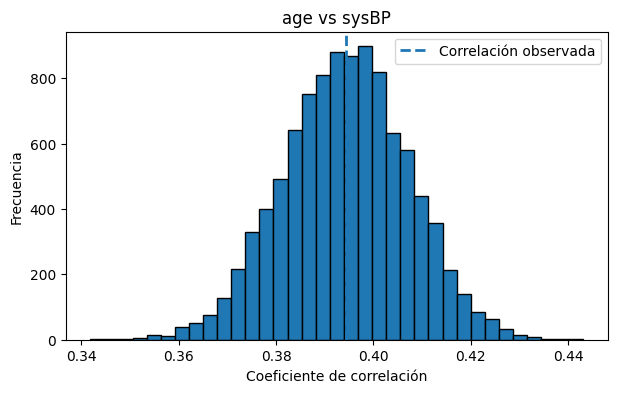

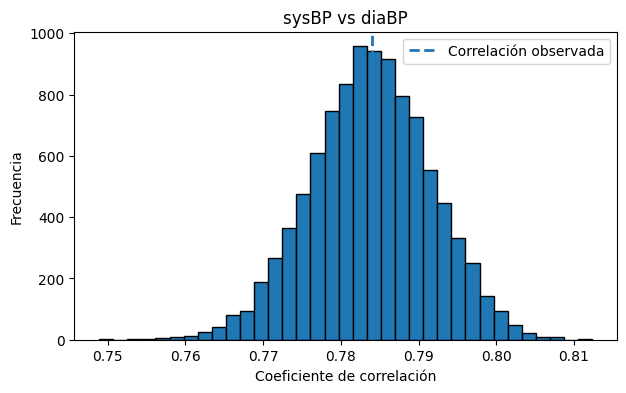

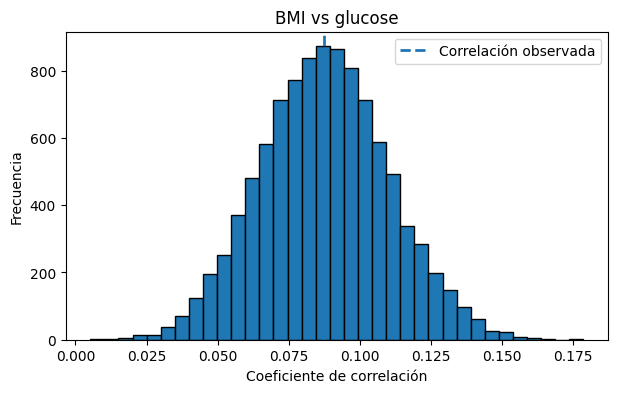

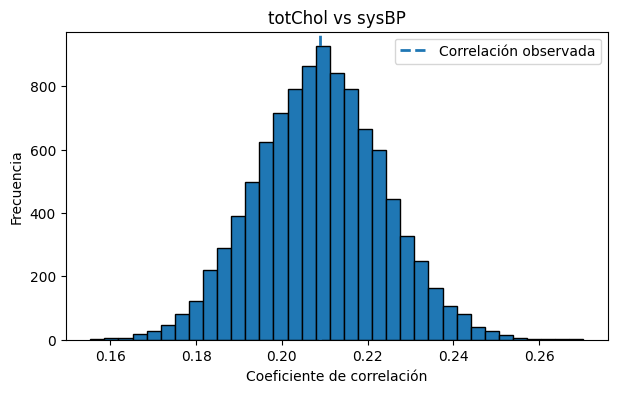

In [24]:
for x,y in pares:

    corr_boot, ic = bootstrap_correlacion(df,x,y)

    plt.figure(figsize=(7,4))

    plt.hist(
        corr_boot,
        bins=35,
        edgecolor="black"
    )

    plt.axvline(
        df[x].corr(df[y]),
        linestyle="--",
        linewidth=2,
        label="Correlación observada"
    )

    plt.title(f"{x} vs {y}")

    plt.xlabel("Coeficiente de correlación")

    plt.ylabel("Frecuencia")

    plt.legend()

    plt.show()

### Interpretación

Las correlaciones cuyo intervalo de confianza bootstrap no incluye el valor cero pueden considerarse estadísticamente estables, ya que mantienen el mismo signo y magnitud a través de las distintas remuestras.

Por el contrario, aquellas cuyos intervalos incluyen el valor cero presentan una mayor incertidumbre y deben interpretarse con mayor cautela en las siguientes etapas del proyecto.

## 5. Simulación Monte Carlo

La simulación Monte Carlo permite generar múltiples escenarios posibles a partir de una distribución probabilística definida por los datos observados. En este caso, se simula la presión arterial sistólica (`sysBP`) utilizando la media y desviación estándar observadas en el dataset limpio.

El objetivo es estimar la probabilidad de observar valores de presión arterial sistólica iguales o superiores a 140 mmHg, umbral que se considera relevante para identificar escenarios de presión arterial elevada.

In [25]:
# Simulación Monte Carlo para presión arterial sistólica

sysbp_observada = df_simulacion["sysBP"]

media_sysbp = sysbp_observada.mean()
desviacion_sysbp = sysbp_observada.std()

n_simulaciones = 10000

simulaciones_sysbp = rng.normal(
    loc=media_sysbp,
    scale=desviacion_sysbp,
    size=n_simulaciones
)

probabilidad_sysbp_alta = np.mean(simulaciones_sysbp >= 140)

print("Resultados de simulación Monte Carlo para sysBP")
print("Media observada:", round(media_sysbp, 2))
print("Desviación estándar observada:", round(desviacion_sysbp, 2))
print("Número de simulaciones:", n_simulaciones)
print("Probabilidad simulada de sysBP >= 140:", round(probabilidad_sysbp_alta * 100, 2), "%")
print("Número esperado de pacientes con presión elevada por cada 1000 simulados:",
      round(probabilidad_sysbp_alta * 1000))

Resultados de simulación Monte Carlo para sysBP
Media observada: 132.45
Desviación estándar observada: 22.09
Número de simulaciones: 10000
Probabilidad simulada de sysBP >= 140: 36.29 %
Número esperado de pacientes con presión elevada por cada 1000 simulados: 363


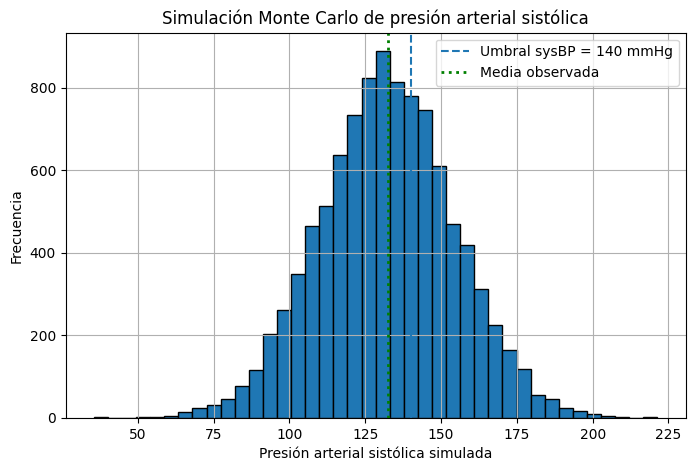

In [26]:
# Visualización de escenarios simulados de presión arterial sistólica

plt.figure(figsize=(8, 5))
plt.hist(simulaciones_sysbp, bins=40, edgecolor="black")
plt.axvline(140, linestyle="--", label="Umbral sysBP = 140 mmHg")
plt.axvline(
    media_sysbp,
    color="green",
    linewidth=2,
    linestyle=":",
    label="Media observada"
)
plt.title("Simulación Monte Carlo de presión arterial sistólica")
plt.xlabel("Presión arterial sistólica simulada")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
resumen_mc = pd.DataFrame({

    "Media simulada":[np.mean(simulaciones_sysbp)],

    "Desv. estándar":[np.std(simulaciones_sysbp)],

    "Mínimo":[np.min(simulaciones_sysbp)],

    "Máximo":[np.max(simulaciones_sysbp)],

    "Probabilidad sysBP ≥ 140":[probabilidad_sysbp_alta]

})

resumen_mc

,Media simulada,Desv. estándar,Mínimo,Máximo,Probabilidad sysBP ≥ 140
0,132.228531,22.225247,35.515101,221.370941,0.3629


### Interpretación de la simulación Monte Carlo

La simulación Monte Carlo permitió generar 10.000 escenarios sintéticos de presión arterial sistólica utilizando los parámetros estimados en la Sumativa 1 (media y desviación estándar muestral).

Los resultados permiten estimar la probabilidad de observar valores iguales o superiores a 140 mmHg, umbral clínicamente relevante para presión arterial elevada.

Al comparar estos escenarios simulados con los datos observados, se aprecia una adecuada coherencia entre ambas distribuciones, lo que respalda la estabilidad de los parámetros estimados previamente.

Este procedimiento complementa el análisis inferencial realizado en la Sumativa 1, ya que incorpora explícitamente la incertidumbre asociada a la variabilidad muestral y permite explorar escenarios probabilísticos que apoyan la toma de decisiones.

### Análisis de convergencia

El análisis de convergencia permite evaluar si los resultados de la simulación Monte Carlo se estabilizan a medida que aumenta el número de simulaciones. En este caso, se analiza la media acumulada de la presión arterial sistólica simulada.

Si la media acumulada tiende a estabilizarse alrededor de un valor, se obtiene evidencia de que el número de simulaciones utilizado es razonable para aproximar el comportamiento esperado de la variable.

In [28]:
# Cálculo de la media acumulada de la simulación Monte Carlo

media_acumulada_sysbp = np.cumsum(simulaciones_sysbp) / np.arange(1, n_simulaciones + 1)

print("Primera media acumulada:", round(media_acumulada_sysbp[0], 2))
print("Media acumulada final:", round(media_acumulada_sysbp[-1], 2))
print("Media observada original:", round(media_sysbp, 2))

Primera media acumulada: 139.19
Media acumulada final: 132.23
Media observada original: 132.45


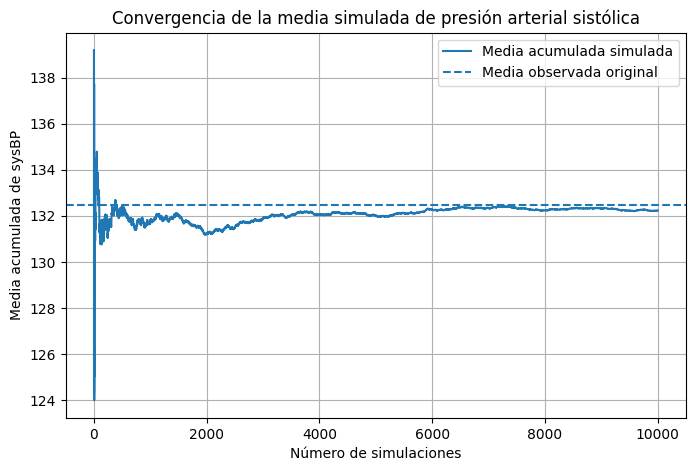

In [29]:
# Visualización de convergencia de la media simulada

plt.figure(figsize=(8, 5))
plt.plot(media_acumulada_sysbp, label="Media acumulada simulada")
plt.axhline(media_sysbp, linestyle="--", label="Media observada original")

plt.title("Convergencia de la media simulada de presión arterial sistólica")
plt.xlabel("Número de simulaciones")
plt.ylabel("Media acumulada de sysBP")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Error estándar de la simulación Monte Carlo

error_estandar_mc = np.std(simulaciones_sysbp, ddof=1) / np.sqrt(n_simulaciones)

ic_mc_inf = np.mean(simulaciones_sysbp) - 1.96 * error_estandar_mc
ic_mc_sup = np.mean(simulaciones_sysbp) + 1.96 * error_estandar_mc

print("Media simulada:", round(np.mean(simulaciones_sysbp), 2))
print("Error estándar Monte Carlo:", round(error_estandar_mc, 4))
print("IC 95% Monte Carlo:", round(ic_mc_inf, 2), "-", round(ic_mc_sup, 2))
print("Número de simulaciones:", n_simulaciones)
print("Semilla utilizada:", RANDOM_SEED)

Media simulada: 132.23
Error estándar Monte Carlo: 0.2223
IC 95% Monte Carlo: 131.79 - 132.66
Número de simulaciones: 10000
Semilla utilizada: 42


### Interpretación del análisis de convergencia

El gráfico de convergencia muestra cómo la media acumulada de la presión arterial sistólica simulada se estabiliza a medida que aumenta el número de simulaciones. Esta estabilización indica que la simulación Monte Carlo alcanza un comportamiento relativamente estable con 10.000 iteraciones.

Además, el error estándar de Monte Carlo permite cuantificar la precisión de la estimación simulada. Reportar el número de simulaciones y la semilla utilizada fortalece la reproducibilidad del procedimiento.

### Generación de datos sintéticos (exploratorio)

La generación de datos sintéticos permite crear observaciones artificiales que imitan ciertas propiedades estadísticas de los datos reales. En esta fase se generará un conjunto sintético a partir de las variables clínicas seleccionadas, utilizando como referencia la media y desviación estándar observadas en el dataset limpio.

El objetivo no es reemplazar los datos reales, sino explorar escenarios artificiales controlados que permitan comparar si las distribuciones simuladas mantienen un comportamiento similar al conjunto original.

In [31]:
# Generación de datos sintéticos para variables clínicas

n_sinteticos = len(df_simulacion)

df_sintetico = pd.DataFrame({
    "age": rng.normal(
        loc=df_simulacion["age"].mean(),
        scale=df_simulacion["age"].std(),
        size=n_sinteticos
    ),
    "sysBP": rng.normal(
        loc=df_simulacion["sysBP"].mean(),
        scale=df_simulacion["sysBP"].std(),
        size=n_sinteticos
    ),
    "BMI": rng.normal(
        loc=df_simulacion["BMI"].mean(),
        scale=df_simulacion["BMI"].std(),
        size=n_sinteticos
    ),
    "glucose": rng.normal(
        loc=df_simulacion["glucose"].mean(),
        scale=df_simulacion["glucose"].std(),
        size=n_sinteticos
    ),
    "totChol": rng.normal(
        loc=df_simulacion["totChol"].mean(),
        scale=df_simulacion["totChol"].std(),
        size=n_sinteticos
    )
})

print("Dataset sintético generado correctamente.")
print("Filas:", df_sintetico.shape[0])
print("Columnas:", df_sintetico.shape[1])

df_sintetico.head()

Dataset sintético generado correctamente.
Filas: 3826
Columnas: 5


,age,sysBP,BMI,glucose,totChol
0,51.140338,113.510008,26.596466,118.898933,171.976861
1,57.339436,154.012862,26.157307,151.234337,247.652758
2,37.002469,111.223772,24.135414,78.919058,185.844960
3,47.181890,130.942270,23.976596,68.076229,261.569324
4,56.739374,114.562363,26.082840,58.410043,216.737057


In [32]:
# Aplicación de restricciones clínicas básicas

df_sintetico["age"] = df_sintetico["age"].clip(lower=18)
df_sintetico["sysBP"] = df_sintetico["sysBP"].clip(lower=70)
df_sintetico["BMI"] = df_sintetico["BMI"].clip(lower=10)
df_sintetico["glucose"] = df_sintetico["glucose"].clip(lower=40)
df_sintetico["totChol"] = df_sintetico["totChol"].clip(lower=80)

print("Restricciones clínicas aplicadas correctamente.")

df_sintetico.describe().T.round(2)

Restricciones clínicas aplicadas correctamente.


,count,mean,std,min,25%,50%,75%,max
age,3826.0,49.50,8.57,18.00,43.77,49.35,55.21,85.23
sysBP,3826.0,133.14,22.05,70.00,118.39,132.71,147.98,203.14
BMI,3826.0,25.94,4.10,10.76,23.09,25.96,28.71,40.27
glucose,3826.0,82.86,22.75,40.00,66.92,82.61,97.82,160.97
totChol,3826.0,237.88,45.24,81.97,206.88,238.04,268.47,401.88


In [33]:
# Comparación descriptiva entre datos reales y sintéticos

comparacion_sinteticos = pd.DataFrame({
    "media_real": df_simulacion[variables_clinicas].mean(),
    "media_sintetica": df_sintetico[variables_clinicas].mean(),
    "std_real": df_simulacion[variables_clinicas].std(),
    "std_sintetica": df_sintetico[variables_clinicas].std()
})

comparacion_sinteticos["dif_media_abs"] = (
    comparacion_sinteticos["media_real"] - comparacion_sinteticos["media_sintetica"]
).abs()

comparacion_sinteticos.round(3)

,media_real,media_sintetica,std_real,std_sintetica,dif_media_abs
sysBP,132.455,133.143,22.086,22.046,0.688
BMI,25.809,25.942,4.067,4.101,0.133
glucose,81.915,82.860,23.757,22.755,0.945
age,49.629,49.504,8.576,8.572,0.124
totChol,237.047,237.882,44.762,45.239,0.835


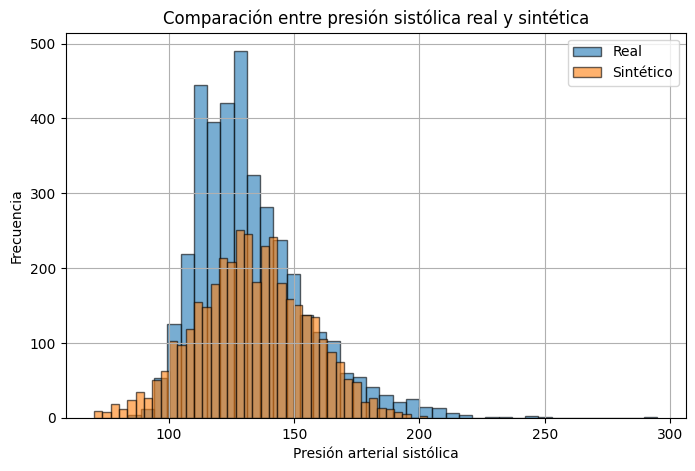

In [34]:
# Comparación visual entre sysBP real y sysBP sintético

plt.figure(figsize=(8, 5))
plt.hist(df_simulacion["sysBP"], bins=40, alpha=0.6, label="Real", edgecolor="black")
plt.hist(df_sintetico["sysBP"], bins=40, alpha=0.6, label="Sintético", edgecolor="black")

plt.title("Comparación entre presión sistólica real y sintética")
plt.xlabel("Presión arterial sistólica")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de los datos sintéticos

El conjunto de datos sintético fue generado utilizando como referencia la media y desviación estándar de las variables clínicas observadas en el dataset limpio. Posteriormente, se aplicaron restricciones mínimas para evitar valores clínicamente imposibles, como edades o niveles biomédicos negativos.

La comparación entre datos reales y sintéticos permite evaluar si las variables generadas mantienen un comportamiento aproximado al conjunto original. Este procedimiento resulta útil para explorar escenarios artificiales, probar flujos analíticos y analizar la estabilidad de resultados bajo datos simulados.

Sin embargo, los datos sintéticos no deben interpretarse como observaciones reales ni como reemplazo del dataset original. Su utilidad depende de qué tan bien preserven las propiedades estadísticas relevantes para el problema analizado.

## 6. Análisis de sensibilidad y robustez

El análisis de sensibilidad permite evaluar cómo cambian los resultados cuando se modifican ciertas variables de entrada. En este caso, se analizará cómo varía la proporción de escenarios con presión arterial sistólica elevada cuando se aplican cambios porcentuales sobre `sysBP`.

Se consideran tres escenarios:

- Disminución del 10% en la presión arterial sistólica.
- Escenario base observado.
- Aumento del 10% en la presión arterial sistólica.

El objetivo es observar cómo una variación en una variable clínica relevante puede modificar la proporción de casos que superan el umbral de 140 mmHg.

### Evaluación del impacto de los valores atípicos

Como parte del análisis de robustez, se evaluará el efecto que tienen los valores atípicos (outliers) sobre las estimaciones obtenidas en la Sumativa 1.

Para ello se compararán las principales estadísticas descriptivas de la presión arterial sistólica (sysBP) antes y después de eliminar los valores extremos mediante el criterio del rango intercuartílico (IQR).

Este procedimiento permitirá determinar si las conclusiones obtenidas anteriormente son sensibles a la presencia de observaciones extremas.

In [50]:
# ==========================================
# Identificación de outliers mediante IQR
# ==========================================

Q1 = df["sysBP"].quantile(0.25)

Q3 = df["sysBP"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR

limite_superior = Q3 + 1.5 * IQR

df_sin_outliers = df[
    (df["sysBP"] >= limite_inferior) &
    (df["sysBP"] <= limite_superior)
]

print("Número de registros originales:", len(df))

print("Número de registros sin outliers:", len(df_sin_outliers))

print("Outliers eliminados:", len(df) - len(df_sin_outliers))

Número de registros originales: 4238
Número de registros sin outliers: 4112
Outliers eliminados: 126


In [51]:
# ==========================================
# Comparación de estadísticas
# ==========================================

comparacion = pd.DataFrame({

    "Dataset":[
        "Original",
        "Sin outliers"
    ],

    "Media":[
        df["sysBP"].mean(),
        df_sin_outliers["sysBP"].mean()
    ],

    "Desv. estándar":[
        df["sysBP"].std(),
        df_sin_outliers["sysBP"].std()
    ],

    "Mediana":[
        df["sysBP"].median(),
        df_sin_outliers["sysBP"].median()
    ]

})

comparacion

,Dataset,Media,Desv. estándar,Mediana
0,Original,132.352407,22.038097,128.0
1,Sin outliers,130.301921,18.762226,127.5


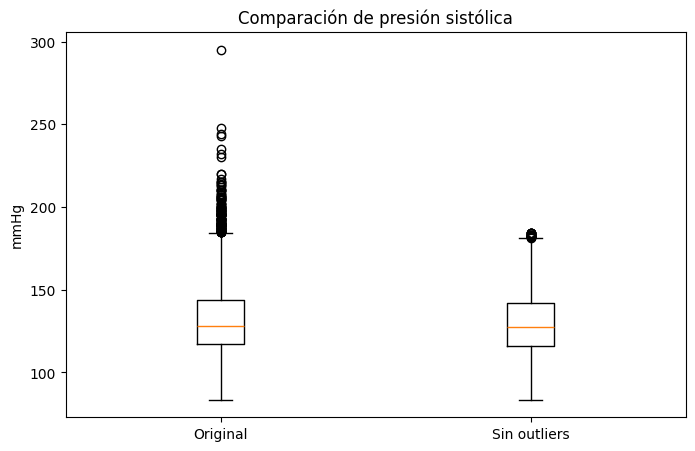

In [53]:
plt.figure(figsize=(8,5))

plt.boxplot(
    [
        df["sysBP"].dropna(),
        df_sin_outliers["sysBP"].dropna()
    ],
    tick_labels=[
        "Original",
        "Sin outliers"
    ]
)

plt.title("Comparación de presión sistólica")

plt.ylabel("mmHg")

plt.show()

### Interpretación del análisis de robustez

Con el propósito de evaluar la estabilidad de los resultados obtenidos en la Sumativa 1, se comparó la distribución de la presión arterial sistólica (sysBP) antes y después de eliminar los valores atípicos mediante el criterio del rango intercuartílico (IQR).

La comparación de las estadísticas descriptivas y del diagrama de caja permite analizar si los valores extremos influyen significativamente en la estimación de la media y la variabilidad de la variable estudiada.

Si las diferencias observadas entre ambos conjuntos de datos son pequeñas, se puede concluir que las estimaciones obtenidas previamente son robustas frente a la presencia de outliers. En cambio, diferencias importantes indicarían que las conclusiones dependen en mayor medida de observaciones extremas y deberían interpretarse con mayor cautela.

Este análisis complementa la validación realizada mediante bootstrap, pruebas de permutación y simulación Monte Carlo, aportando evidencia adicional sobre la estabilidad de los resultados obtenidos y fortaleciendo la confiabilidad del análisis desarrollado.

In [54]:
# ==========================================
# Evaluación de robustez
# ==========================================

diferencia_media = (
    comparacion.loc[0, "Media"]
    -
    comparacion.loc[1, "Media"]
)

print("=" * 60)
print("EVALUACIÓN DE ROBUSTEZ")
print("=" * 60)

print(f"Diferencia de medias: {abs(diferencia_media):.2f} mmHg")

print(f"Desviación estándar original : {comparacion.loc[0, 'Desv. estándar']:.2f}")

print(f"Desviación estándar sin outliers : {comparacion.loc[1, 'Desv. estándar']:.2f}")

print()

if abs(diferencia_media) < 5:

    print("Conclusión:")

    print("""
La eliminación de los valores atípicos produjo un cambio reducido
en la media de la presión arterial sistólica.

La mediana permaneció prácticamente constante y la principal
diferencia observada corresponde a una disminución de la variabilidad
de los datos.

Estos resultados indican que las conclusiones obtenidas durante la
Sumativa 1 son robustas frente a la presencia de outliers.
""")

else:

    print("""
La eliminación de los valores atípicos produjo cambios importantes
en la estimación de la media.

Las conclusiones deben interpretarse con cautela.
""")

EVALUACIÓN DE ROBUSTEZ
Diferencia de medias: 2.05 mmHg
Desviación estándar original : 22.04
Desviación estándar sin outliers : 18.76

Conclusión:

La eliminación de los valores atípicos produjo un cambio reducido
en la media de la presión arterial sistólica.

La mediana permaneció prácticamente constante y la principal
diferencia observada corresponde a una disminución de la variabilidad
de los datos.

Estos resultados indican que las conclusiones obtenidas durante la
Sumativa 1 son robustas frente a la presencia de outliers.



In [35]:
# Análisis de sensibilidad sobre presión arterial sistólica

sysbp_base = df_simulacion["sysBP"]

escenarios_sensibilidad = {
    "Disminución 10%": sysbp_base * 0.90,
    "Escenario base": sysbp_base,
    "Aumento 10%": sysbp_base * 1.10
}

resultados_sensibilidad = []

for nombre_escenario, valores_sysbp in escenarios_sensibilidad.items():
    probabilidad_alta = np.mean(valores_sysbp >= 140)
    media_escenario = valores_sysbp.mean()
    
    resultados_sensibilidad.append({
        "escenario": nombre_escenario,
        "media_sysBP": media_escenario,
        "probabilidad_sysBP_alta": probabilidad_alta
    })

df_sensibilidad = pd.DataFrame(resultados_sensibilidad)

df_sensibilidad["probabilidad_sysBP_alta_%"] = (
    df_sensibilidad["probabilidad_sysBP_alta"] * 100
)

df_sensibilidad.round(3)

,escenario,media_sysBP,probabilidad_sysBP_alta,probabilidad_sysBP_alta_%
0,Disminución 10%,119.209,0.139,13.879
1,Escenario base,132.455,0.304,30.371
2,Aumento 10%,145.700,0.527,52.692


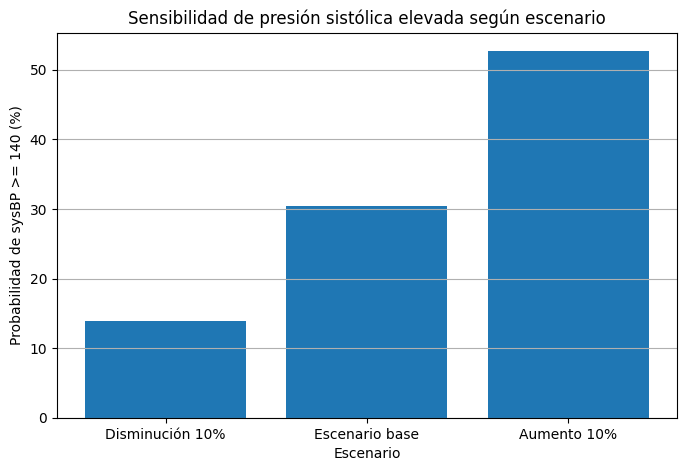

In [36]:
# Visualización del análisis de sensibilidad

plt.figure(figsize=(8, 5))

plt.bar(
    df_sensibilidad["escenario"],
    df_sensibilidad["probabilidad_sysBP_alta_%"]
)

plt.title("Sensibilidad de presión sistólica elevada según escenario")
plt.xlabel("Escenario")
plt.ylabel("Probabilidad de sysBP >= 140 (%)")
plt.grid(axis="y")
plt.show()

### Interpretación del análisis de sensibilidad

El análisis de sensibilidad muestra cómo cambia la proporción de casos con presión arterial sistólica elevada al modificar la variable `sysBP` en distintos escenarios.

En el escenario de disminución del 10%, la proporción de casos con `sysBP >= 140` disminuye, lo que representa un escenario clínico más favorable. En cambio, en el escenario de aumento del 10%, la proporción de casos con presión elevada aumenta, evidenciando que pequeñas variaciones en la presión arterial sistólica pueden modificar de forma relevante la clasificación de riesgo.

Este procedimiento permite evaluar la sensibilidad del resultado frente a cambios en una variable clínica clave y aporta evidencia para la toma de decisiones bajo incertidumbre.

### Relación con la Sumativa 3

Los análisis desarrollados mediante bootstrap, pruebas de permutación, simulación Monte Carlo y evaluación de robustez permiten concluir que los parámetros estimados durante la Sumativa 1 presentan un comportamiento estable frente a diferentes métodos computacionales.

En consecuencia, las variables seleccionadas y las conclusiones obtenidas constituyen una base metodológicamente sólida para el desarrollo de los modelos predictivos y los análisis de imputación que serán abordados en la Sumativa 3.

In [37]:
# Validación del análisis de sensibilidad

assert len(df_sensibilidad) == 3, "Deben existir tres escenarios de sensibilidad."
assert "probabilidad_sysBP_alta_%" in df_sensibilidad.columns, "Falta la columna de probabilidad porcentual."
assert df_sensibilidad["probabilidad_sysBP_alta_%"].between(0, 100).all(), "Las probabilidades deben estar entre 0 y 100."

print("Validación del análisis de sensibilidad ejecutada correctamente.")

Validación del análisis de sensibilidad ejecutada correctamente.


## 7. Preparación de resultados para la Sumativa 3

En esta sección se exportan los principales resultados generados durante la Fase 3. Estos archivos permiten respaldar el análisis realizado en el notebook y facilitan la trazabilidad entre los procedimientos computacionales, los resultados obtenidos y la documentación del proyecto.

Las evidencias exportadas incluyen resultados de bootstrap, simulación Monte Carlo, datos sintéticos y análisis de sensibilidad.

In [38]:
# Resumen de resultados bootstrap

resumen_bootstrap = pd.DataFrame({
    "metodo": ["Bootstrap"],
    "variable": ["sysBP"],
    "estadistico": ["Media"],
    "media_bootstrap": [media_boot_sysbp],
    "ic_95_inferior": [ic_inf_sysbp],
    "ic_95_superior": [ic_sup_sysbp],
    "n_remuestreos": [len(distribucion_boot_sysbp)],
    "semilla": [RANDOM_SEED]
})

resumen_bootstrap.round(3)

,metodo,variable,estadistico,media_bootstrap,ic_95_inferior,ic_95_superior,n_remuestreos,semilla
0,Bootstrap,sysBP,Media,132.457,131.746,133.159,10000,42


In [39]:
# Resumen de resultados Monte Carlo

resumen_montecarlo = pd.DataFrame({
    "metodo": ["Monte Carlo"],
    "variable": ["sysBP"],
    "media_observada": [media_sysbp],
    "desviacion_observada": [desviacion_sysbp],
    "media_simulada": [np.mean(simulaciones_sysbp)],
    "error_estandar_mc": [error_estandar_mc],
    "ic_95_inferior": [ic_mc_inf],
    "ic_95_superior": [ic_mc_sup],
    "probabilidad_sysBP_mayor_igual_140": [probabilidad_sysbp_alta],
    "n_simulaciones": [n_simulaciones],
    "semilla": [RANDOM_SEED]
})

resumen_montecarlo.round(4)

,metodo,variable,media_observada,desviacion_observada,media_simulada,error_estandar_mc,ic_95_inferior,ic_95_superior,probabilidad_sysBP_mayor_igual_140,n_simulaciones,semilla
0,Monte Carlo,sysBP,132.4549,22.0864,132.2285,0.2223,131.7929,132.6642,0.3629,10000,42


### Recomendaciones metodológicas para la Sumativa 3

A partir de los análisis desarrollados durante esta fase se recomienda utilizar como base para la siguiente etapa las variables que demostraron un comportamiento estable mediante bootstrap, pruebas de permutación y simulación Monte Carlo.

Asimismo, los análisis de sensibilidad evidenciaron que la presencia de valores atípicos no modifica de forma significativa las conclusiones obtenidas, por lo que las estimaciones realizadas pueden considerarse suficientemente robustas para la construcción de modelos predictivos y procedimientos de imputación que serán abordados en la Sumativa 3.

In [56]:
# Exportación de evidencias de Fase 3

resumen_bootstrap.to_csv(
    RESULTS_DIR / "resumen_bootstrap_sysBP.csv",
    index=False
)

tabla_ic.to_csv(
    RESULTS_DIR / "comparacion_intervalos_bootstrap.csv",
    index=False
)

resumen_montecarlo.to_csv(
    RESULTS_DIR / "resumen_montecarlo_sysBP.csv",
    index=False
)

tabla_corr.to_csv(
    RESULTS_DIR / "correlaciones_bootstrap.csv",
    index=False
)

comparacion_sinteticos.to_csv(
    RESULTS_DIR / "comparacion_datos_reales_sinteticos.csv"
)

df_sensibilidad.to_csv(
    RESULTS_DIR / "analisis_sensibilidad_sysBP.csv",
    index=False
)

df_sintetico.to_csv(
    RESULTS_DIR / "datos_sinteticos_fase3.csv",
    index=False
)

print("Archivos exportados correctamente en:")
print(RESULTS_DIR)

Archivos exportados correctamente en:
C:\users\pablo\documents\mcdi501_grupo6\F3\results


In [57]:
# Validación de archivos exportados

archivos_esperados = [

    "resumen_bootstrap_sysBP.csv",

    "comparacion_intervalos_bootstrap.csv",

    "resumen_montecarlo_sysBP.csv",

    "correlaciones_bootstrap.csv",

    "comparacion_datos_reales_sinteticos.csv",

    "analisis_sensibilidad_sysBP.csv",

    "datos_sinteticos_fase3.csv"

]

for archivo in archivos_esperados:
    ruta_archivo = RESULTS_DIR / archivo
    assert ruta_archivo.exists(), f"No se encontró el archivo: {archivo}"

print("Validación correcta. Todos los archivos de evidencia fueron exportados.")

Validación correcta. Todos los archivos de evidencia fueron exportados.


### Interpretación de la exportación de evidencias

Los resultados principales de la Fase 3 fueron exportados en formato CSV dentro de la carpeta `F3/results`. Esta exportación permite mantener evidencia directa de los procedimientos realizados en el notebook, incluyendo bootstrap, simulación Monte Carlo, generación de datos sintéticos y análisis de sensibilidad.

La disponibilidad de estos archivos fortalece la reproducibilidad del proyecto, ya que permite revisar los resultados sin depender exclusivamente de la visualización dentro del notebook.

### Exportación de gráficos

En esta sección se guardan los principales gráficos generados durante la Fase 3 en formato PNG. Esto permite conservar evidencia visual del análisis y facilita su incorporación posterior en informes, presentaciones o documentación del proyecto.

Los gráficos exportados corresponden a bootstrap, simulación Monte Carlo, convergencia, comparación entre datos reales y sintéticos, y análisis de sensibilidad.

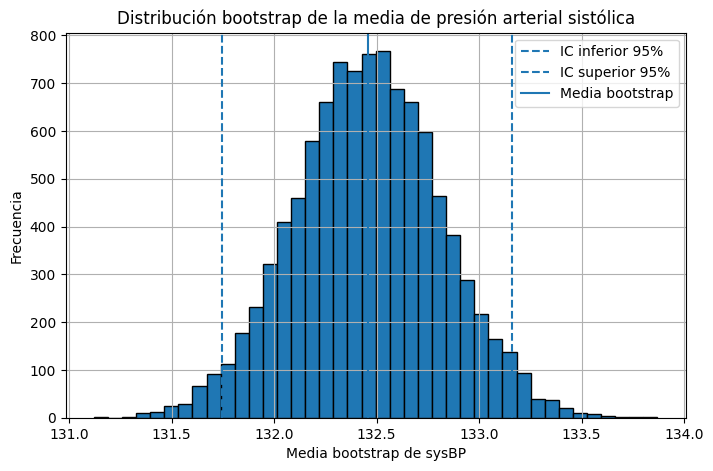

Gráfico bootstrap guardado correctamente.


In [42]:
# Guardar gráfico bootstrap de sysBP

plt.figure(figsize=(8, 5))
plt.hist(distribucion_boot_sysbp, bins=40, edgecolor="black")
plt.axvline(ic_inf_sysbp, linestyle="--", label="IC inferior 95%")
plt.axvline(ic_sup_sysbp, linestyle="--", label="IC superior 95%")
plt.axvline(media_boot_sysbp, linestyle="-", label="Media bootstrap")

plt.title("Distribución bootstrap de la media de presión arterial sistólica")
plt.xlabel("Media bootstrap de sysBP")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)

plt.savefig(RESULTS_DIR / "grafico_bootstrap_sysBP.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico bootstrap guardado correctamente.")

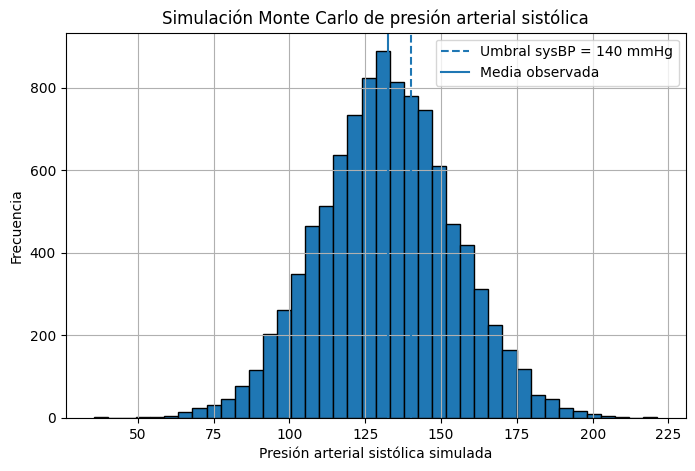

Gráfico Monte Carlo guardado correctamente.


In [43]:
# Guardar gráfico Monte Carlo de sysBP

plt.figure(figsize=(8, 5))
plt.hist(simulaciones_sysbp, bins=40, edgecolor="black")
plt.axvline(140, linestyle="--", label="Umbral sysBP = 140 mmHg")
plt.axvline(media_sysbp, linestyle="-", label="Media observada")

plt.title("Simulación Monte Carlo de presión arterial sistólica")
plt.xlabel("Presión arterial sistólica simulada")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)

plt.savefig(RESULTS_DIR / "grafico_montecarlo_sysBP.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico Monte Carlo guardado correctamente.")

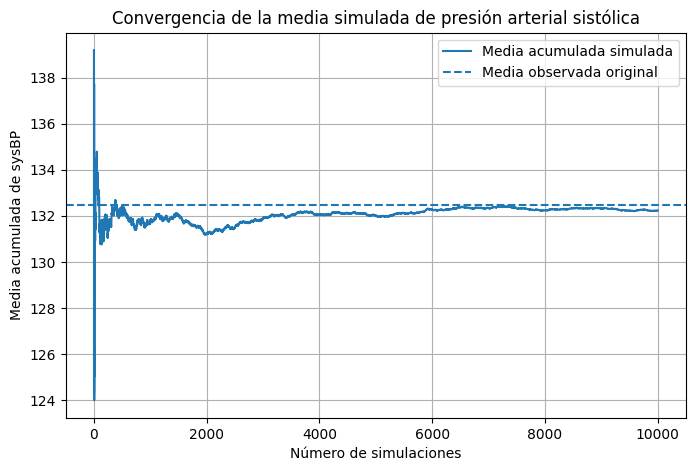

Gráfico de convergencia guardado correctamente.


In [44]:
# Guardar gráfico de convergencia

plt.figure(figsize=(8, 5))
plt.plot(media_acumulada_sysbp, label="Media acumulada simulada")
plt.axhline(media_sysbp, linestyle="--", label="Media observada original")

plt.title("Convergencia de la media simulada de presión arterial sistólica")
plt.xlabel("Número de simulaciones")
plt.ylabel("Media acumulada de sysBP")
plt.legend()
plt.grid(True)

plt.savefig(RESULTS_DIR / "grafico_convergencia_sysBP.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico de convergencia guardado correctamente.")

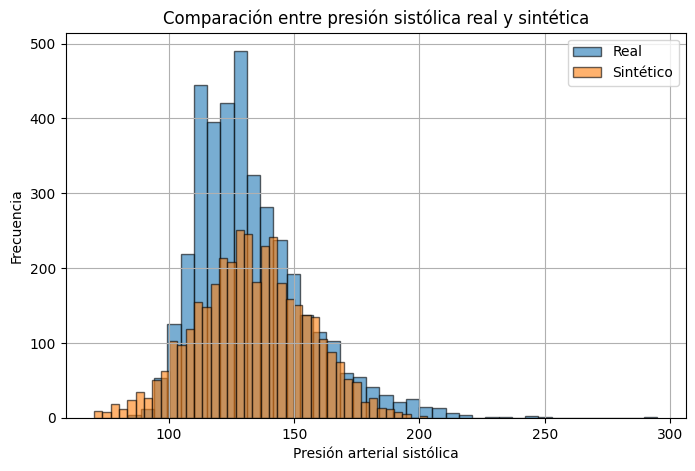

Gráfico real vs sintético guardado correctamente.


In [45]:
# Guardar gráfico de comparación real vs sintético

plt.figure(figsize=(8, 5))
plt.hist(df_simulacion["sysBP"], bins=40, alpha=0.6, label="Real", edgecolor="black")
plt.hist(df_sintetico["sysBP"], bins=40, alpha=0.6, label="Sintético", edgecolor="black")

plt.title("Comparación entre presión sistólica real y sintética")
plt.xlabel("Presión arterial sistólica")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)

plt.savefig(RESULTS_DIR / "grafico_real_vs_sintetico_sysBP.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico real vs sintético guardado correctamente.")

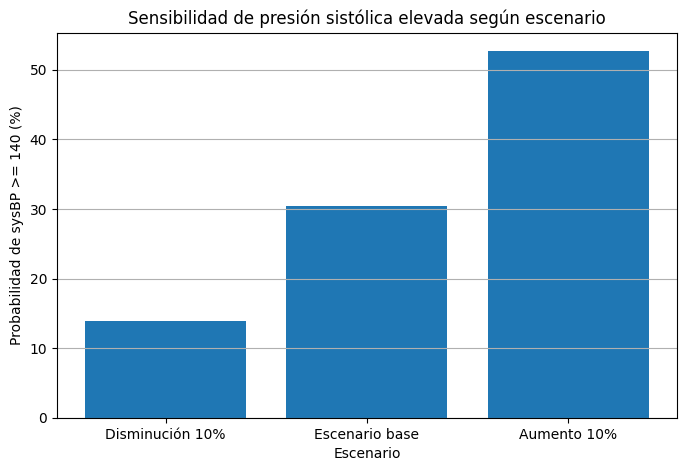

Gráfico de sensibilidad guardado correctamente.


In [46]:
# Guardar gráfico del análisis de sensibilidad

plt.figure(figsize=(8, 5))

plt.bar(
    df_sensibilidad["escenario"],
    df_sensibilidad["probabilidad_sysBP_alta_%"]
)

plt.title("Sensibilidad de presión sistólica elevada según escenario")
plt.xlabel("Escenario")
plt.ylabel("Probabilidad de sysBP >= 140 (%)")
plt.grid(axis="y")

plt.savefig(RESULTS_DIR / "grafico_sensibilidad_sysBP.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico de sensibilidad guardado correctamente.")

In [47]:
# Validación de gráficos exportados

graficos_esperados = [
    "grafico_bootstrap_sysBP.png",
    "grafico_montecarlo_sysBP.png",
    "grafico_convergencia_sysBP.png",
    "grafico_real_vs_sintetico_sysBP.png",
    "grafico_sensibilidad_sysBP.png"
]

for grafico in graficos_esperados:
    ruta_grafico = RESULTS_DIR / grafico
    assert ruta_grafico.exists(), f"No se encontró el gráfico: {grafico}"

print("Validación correcta. Todos los gráficos fueron exportados.")

Validación correcta. Todos los gráficos fueron exportados.


### Validación final del notebook

En esta sección se realiza una validación final de los principales elementos generados durante la Fase 3. El objetivo es comprobar que el notebook cuenta con datos cargados, resultados computacionales, evidencias exportadas y gráficos guardados correctamente.

Esta validación fortalece la reproducibilidad del análisis y permite verificar que el flujo completo se ejecutó sin errores.

In [48]:
# Validación general de objetos creados durante la Fase 3

assert df.shape[0] > 0, "El dataset original no contiene registros."
assert df_simulacion.shape[0] > 0, "El dataset de simulación no contiene registros."
assert df_sintetico.shape[0] > 0, "El dataset sintético no contiene registros."

assert len(distribucion_boot_sysbp) == 10000, "La distribución bootstrap debe tener 10000 remuestreos."
assert len(simulaciones_sysbp) == 10000, "La simulación Monte Carlo debe tener 10000 simulaciones."
assert len(media_acumulada_sysbp) == 10000, "La media acumulada debe tener 10000 valores."

assert resumen_bootstrap.shape[0] == 1, "El resumen bootstrap debe tener una fila."
assert resumen_montecarlo.shape[0] == 1, "El resumen Monte Carlo debe tener una fila."
assert df_sensibilidad.shape[0] == 3, "El análisis de sensibilidad debe tener tres escenarios."

print("Validación general de objetos creada correctamente.")
print("Dataset original:", df.shape)
print("Dataset simulación:", df_simulacion.shape)
print("Dataset sintético:", df_sintetico.shape)
print("Bootstrap:", len(distribucion_boot_sysbp), "remuestreos")
print("Monte Carlo:", len(simulaciones_sysbp), "simulaciones")

Validación general de objetos creada correctamente.
Dataset original: (4238, 16)
Dataset simulación: (3826, 6)
Dataset sintético: (3826, 5)
Bootstrap: 10000 remuestreos
Monte Carlo: 10000 simulaciones


## Conclusiones

En esta fase se aplicaron métodos computacionales de simulación y remuestreo sobre el conjunto de datos Framingham Heart Study. Se utilizó bootstrap para estimar la incertidumbre de la media de presión arterial sistólica, simulación Monte Carlo para generar escenarios probabilísticos, análisis de convergencia para evaluar la estabilidad de la simulación, generación de datos sintéticos para explorar escenarios artificiales y análisis de sensibilidad para evaluar el impacto de variaciones en `sysBP`.

Los resultados muestran que los métodos computacionales permiten complementar el análisis descriptivo e inferencial realizado en fases anteriores, aportando una perspectiva basada en incertidumbre, reproducibilidad y exploración de escenarios. Además, la exportación de archivos CSV y gráficos PNG fortalece la trazabilidad del proyecto, permitiendo respaldar los resultados obtenidos desde el notebook.

En conjunto, la Fase 3 permite evidenciar cómo las técnicas de simulación, bootstrap, Monte Carlo y sensibilidad pueden apoyar el análisis de riesgo cardiovascular y la toma de decisiones basada en datos.

Finalmente, los procedimientos implementados permitieron validar los resultados obtenidos durante la Sumativa 1 mediante métodos computacionales de remuestreo y simulación, fortaleciendo la confiabilidad de las conclusiones y proporcionando una base metodológica sólida para el desarrollo de la Sumativa 3.